# **MÓDULO 39 - Exercicio - Aplicando XGboost**

Nessa atividade vocês usarão uma base já connhecida, a base de propensão a compra de carros.
Já utilizamos essa base antes, nessa atividade, você deve carregar a base, realizar os tratamentos necessários, rodar o XGBoost, encontrar as principais variaveis.
Vamos lá!

In [2]:
!pip install xgboost

In [4]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# 1. Carrega a base de dados, verifique os tipos de dados, dados faltantes e drop a coluna ID.


In [5]:
# 1. Carregar base de dados
df = pd.read_csv('CARRO_CLIENTES (1).csv')

# Visualizar primeiras linhas
print("=" * 50)
print(" PRIMEIRAS LINHAS")
print("=" * 50)
print(df.head())

# Tipos de dados
print("\n" + "=" * 50)
print(" TIPOS DE DADOS")
print("=" * 50)
print(df.dtypes)

# Dados faltantes
print("\n" + "=" * 50)
print(" DADOS FALTANTES")
print("=" * 50)
print(df.isnull().sum())

# Shape antes do drop
print(f"\nShape antes: {df.shape}")

# Drop coluna ID
df.drop(columns=['User ID'], inplace=True)

# Shape depois do drop
print(f"Shape depois: {df.shape}")
print(f"\nColunas restantes: {df.columns.tolist()}")


 PRIMEIRAS LINHAS
   User ID Gender  Age  AnnualSalary  Purchased
0      385   Male   35         20000          0
1      681   Male   40         43500          0
2      353   Male   49         74000          0
3      895   Male   40        107500          1
4      661   Male   25         79000          0

 TIPOS DE DADOS
User ID          int64
Gender          object
Age              int64
AnnualSalary     int64
Purchased        int64
dtype: object

 DADOS FALTANTES
User ID         0
Gender          0
Age             0
AnnualSalary    0
Purchased       0
dtype: int64

Shape antes: (1000, 5)
Shape depois: (1000, 4)

Colunas restantes: ['Gender', 'Age', 'AnnualSalary', 'Purchased']


# 2. Aplique o Label Encoder para a coluna Gender e exclua a coluna categórica.

In [6]:
# Label Encoder para Gender
le = LabelEncoder()
df['Gender_enc'] = le.fit_transform(df['Gender'])

# Verificar mapeamento
print("Mapeamento:")
for classe, codigo in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {classe} -> {codigo}")

# Excluir coluna categorica original
df.drop(columns=['Gender'], inplace=True)

print(f"\nColunas atuais: {df.columns.tolist()}")
print(f"\n{df.head()}")


Mapeamento:
  Female -> 0
  Male -> 1

Colunas atuais: ['Age', 'AnnualSalary', 'Purchased', 'Gender_enc']

   Age  AnnualSalary  Purchased  Gender_enc
0   35         20000          0           1
1   40         43500          0           1
2   49         74000          0           1
3   40        107500          1           1
4   25         79000          0           1


# 3. Faça a matriz de correlação e analise as váriaveis que parecem ter maior correlação com a váriavel target.

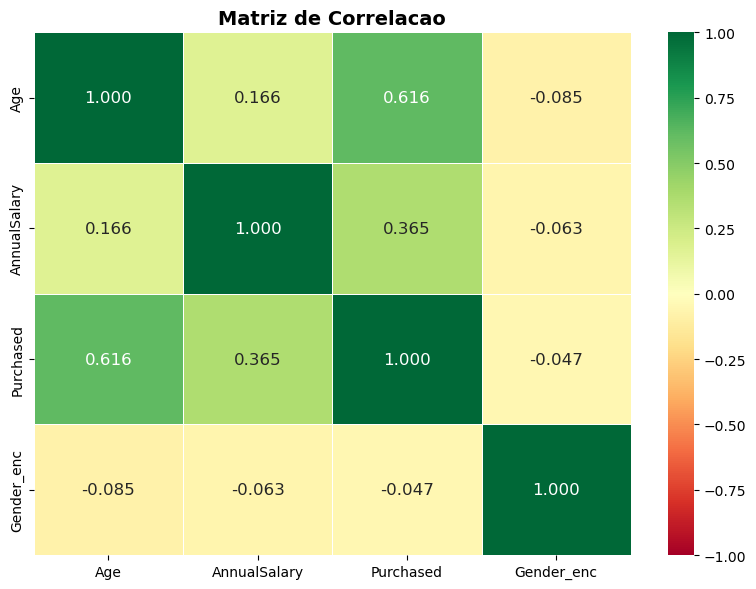

 CORRELACAO COM A TARGET (Purchased)
Age             0.616036
AnnualSalary    0.364974
Gender_enc     -0.047211


In [7]:
# Matriz de correlacao
corr = df.corr()

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 12})
plt.title('Matriz de Correlacao', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlacao com a target
print("=" * 50)
print(" CORRELACAO COM A TARGET (Purchased)")
print("=" * 50)
corr_target = corr['Purchased'].drop('Purchased').sort_values(ascending=False)
print(corr_target.to_string())


# 4. Faça a separação da base em X e Y e em seguida nas bases de treino e teste.

In [8]:
# Separacao X e Y
X = df.drop(columns=['Purchased'])
Y = df['Purchased']

print("=" * 50)
print(" DEFINICAO X e Y")
print("=" * 50)
print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")
print(f"\nFeatures: {X.columns.tolist()}")
print(f"\nDistribuicao Y:")
print(Y.value_counts())

# Separacao treino e teste (80/20 estratificado)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=42, stratify=Y
)

print(f"\n{'=' * 50}")
print(f" TREINO / TESTE")
print(f"{'=' * 50}")
print(f"X_train: {X_train.shape}  |  Y_train: {Y_train.shape}")
print(f"X_test:  {X_test.shape}   |  Y_test:  {Y_test.shape}")
print(f"\nProporcao Y treino:\n{Y_train.value_counts(normalize=True).round(4) * 100}")
print(f"\nProporcao Y teste:\n{Y_test.value_counts(normalize=True).round(4) * 100}")


 DEFINICAO X e Y
X shape: (1000, 3)
Y shape: (1000,)

Features: ['Age', 'AnnualSalary', 'Gender_enc']

Distribuicao Y:
Purchased
0    598
1    402
Name: count, dtype: int64

 TREINO / TESTE
X_train: (800, 3)  |  Y_train: (800,)
X_test:  (200, 3)   |  Y_test:  (200,)

Proporcao Y treino:
Purchased
0    59.75
1    40.25
Name: proportion, dtype: float64

Proporcao Y teste:
Purchased
0    60.0
1    40.0
Name: proportion, dtype: float64


# 5. Treino o modelo Xgboost com sua base de treino.
Pesquise alguns hyperparametros na bibllioteca para utilizar, utilize ao menos 2.

In [9]:
# Treino do modelo XGBoost
model = xgb.XGBClassifier(
    n_estimators=200,          # numero de arvores
    max_depth=6,               # profundidade maxima de cada arvore
    learning_rate=0.05,        # taxa de aprendizado (menor = mais conservador)
    subsample=0.8,             # % de amostras usadas por arvore
    colsample_bytree=0.8,      # % de features usadas por arvore
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

model.fit(X_train, Y_train)

print("=" * 50)
print(" MODELO XGBOOST TREINADO")
print("=" * 50)
print(f"\nHyperparametros configurados:")
print(f"  n_estimators   = 200  (numero de arvores)")
print(f"  max_depth      = 6    (profundidade maxima)")
print(f"  learning_rate  = 0.05 (taxa de aprendizado)")
print(f"  subsample      = 0.8  (amostragem por arvore)")
print(f"  colsample_bytree = 0.8 (features por arvore)")


 MODELO XGBOOST TREINADO

Hyperparametros configurados:
  n_estimators   = 200  (numero de arvores)
  max_depth      = 6    (profundidade maxima)
  learning_rate  = 0.05 (taxa de aprendizado)
  subsample      = 0.8  (amostragem por arvore)
  colsample_bytree = 0.8 (features por arvore)


# 6. Realize as previsões para a base de teste e traga as probabilidades das previsões.

In [10]:
# Previsoes e probabilidades
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

print("=" * 50)
print(" PREVISOES REALIZADAS")
print("=" * 50)
print(f"Total de previsoes: {len(y_pred)}")
print(f"\nDistribuicao das previsoes:")
print(pd.Series(y_pred).value_counts().rename({0: 'Nao comprou (0)', 1: 'Comprou (1)'}))

print(f"\n{'=' * 50}")
print(f" PROBABILIDADES (primeiros 10 registros)")
print(f"{'=' * 50}")

df_proba = pd.DataFrame({
    'Real': Y_test.values[:10],
    'Previsto': y_pred[:10],
    'Prob Nao Comprar (0)': y_proba[:10, 0].round(4),
    'Prob Comprar (1)': y_proba[:10, 1].round(4)
})
print(df_proba.to_string(index=False))


 PREVISOES REALIZADAS
Total de previsoes: 200

Distribuicao das previsoes:
Nao comprou (0)    121
Comprou (1)         79
Name: count, dtype: int64

 PROBABILIDADES (primeiros 10 registros)
 Real  Previsto  Prob Nao Comprar (0)  Prob Comprar (1)
    0         0                0.9889            0.0111
    1         1                0.0133            0.9867
    1         1                0.0535            0.9465
    1         1                0.0681            0.9319
    0         0                0.9934            0.0066
    0         0                0.9818            0.0182
    1         1                0.1875            0.8125
    1         1                0.0925            0.9075
    0         0                0.9994            0.0006
    0         0                0.9845            0.0155


# 7. Faça a transformação das probabilidades nas previsões binárias e avalie o desempenho do modelo.

 THRESHOLD UTILIZADO: 0.5

Distribuicao das previsoes binarias:
Nao comprou (0)    121
Comprou (1)         79
Name: count, dtype: int64

 ACCURACY
  0.8950 (89.50%)

 CLASSIFICATION REPORT
                 precision    recall  f1-score   support

Nao comprou (0)       0.91      0.92      0.91       120
    Comprou (1)       0.87      0.86      0.87        80

       accuracy                           0.90       200
      macro avg       0.89      0.89      0.89       200
   weighted avg       0.89      0.90      0.89       200

 MATRIZ DE CONFUSAO


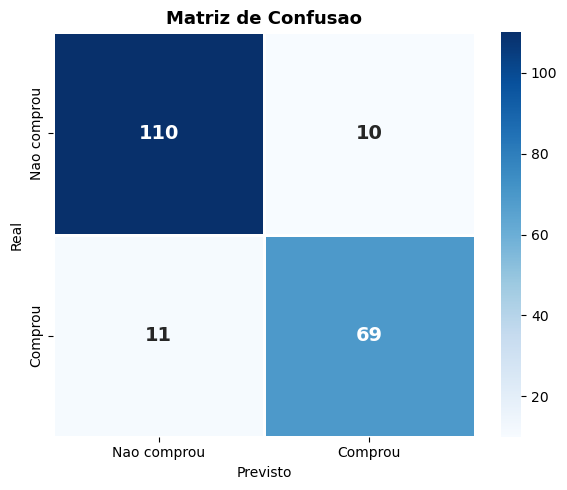


  Verdadeiros Negativos (VN): 110
  Falsos Positivos (FP):     10
  Falsos Negativos (FN):     11
  Verdadeiros Positivos (VP): 69


In [11]:
#Transformacao de probabilidades em previsoes binarias
threshold = 0.5
y_pred_binary = (y_proba[:, 1] >= threshold).astype(int)

print("=" * 50)
print(f" THRESHOLD UTILIZADO: {threshold}")
print("=" * 50)
print(f"\nDistribuicao das previsoes binarias:")
print(pd.Series(y_pred_binary).value_counts().rename({0: 'Nao comprou (0)', 1: 'Comprou (1)'}))

# Avaliacao do desempenho
print(f"\n{'=' * 50}")
print(f" ACCURACY")
print(f"{'=' * 50}")
acc = accuracy_score(Y_test, y_pred_binary)
print(f"  {acc:.4f} ({acc*100:.2f}%)")

print(f"\n{'=' * 50}")
print(f" CLASSIFICATION REPORT")
print(f"{'=' * 50}")
print(classification_report(Y_test, y_pred_binary,
      target_names=['Nao comprou (0)', 'Comprou (1)']))

print(f"{'=' * 50}")
print(f" MATRIZ DE CONFUSAO")
print(f"{'=' * 50}")
cm = confusion_matrix(Y_test, y_pred_binary)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Nao comprou', 'Comprou'],
            yticklabels=['Nao comprou', 'Comprou'],
            linewidths=1, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Matriz de Confusao', fontsize=13, fontweight='bold')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\n  Verdadeiros Negativos (VN): {tn}")
print(f"  Falsos Positivos (FP):     {fp}")
print(f"  Falsos Negativos (FN):     {fn}")
print(f"  Verdadeiros Positivos (VP): {tp}")


# 8. Traga a lista com a feature importance.
As features mais importantes são as mesmas que indicaram maior correlação na matriz de correlação?

 FEATURE IMPORTANCE (XGBoost)
  Age                  0.5068
  AnnualSalary         0.4036
  Gender_enc           0.0896


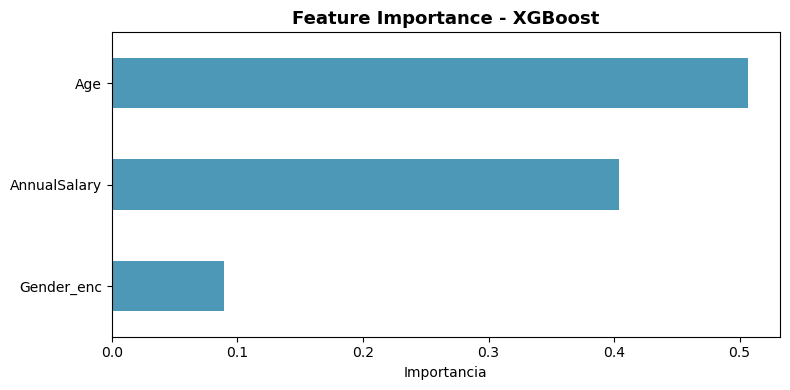


 COMPARATIVO: FEATURE IMPORTANCE vs CORRELACAO
              Rank Correlacao  Correlacao (abs)  Rank Importance  Importance
Age                         1            0.6160                1      0.5068
AnnualSalary                2            0.3650                2      0.4036
Gender_enc                  3            0.0472                3      0.0896


In [12]:
# Feature Importance
importances = pd.Series(model.feature_importances_,
                         index=X_train.columns).sort_values(ascending=False)

print("=" * 50)
print(" FEATURE IMPORTANCE (XGBoost)")
print("=" * 50)
for feat, imp in importances.items():
    print(f"  {feat:20s} {imp:.4f}")

# Grafico
plt.figure(figsize=(8, 4))
importances.sort_values(ascending=True).plot(kind='barh', color='#2E86AB', alpha=0.85)
plt.title('Feature Importance - XGBoost', fontsize=13, fontweight='bold')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

# Comparativo com correlacao
print(f"\n{'=' * 50}")
print(" COMPARATIVO: FEATURE IMPORTANCE vs CORRELACAO")
print("=" * 50)

corr_target = df.corr()['Purchased'].drop('Purchased').abs().sort_values(ascending=False)

comparativo = pd.DataFrame({
    'Rank Correlacao': range(1, len(corr_target) + 1),
    'Correlacao (abs)': corr_target.values.round(4)
}, index=corr_target.index)

comparativo['Rank Importance'] = [list(importances.index).index(f) + 1 for f in corr_target.index]
comparativo['Importance'] = [importances[f].round(4) for f in corr_target.index]

print(comparativo.to_string())


* INSIGHTS:

O ranking é idêntico! A ordem das features mais importantes no XGBoost é exatamente a mesma da matriz de correlação. O que faz sentido, já que a idade é o fator mais determinante na decisão de compra do carro, seguida pelo salário anual. O gênero tem influência mínima em ambas as analises, sendo praticamente irrelevante para a decisãoo de compra.


